# Matplotlib with pandas - real data

In [95]:
import pandas as pd

df = pd.read_csv("retail_store_sales.csv")
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# Remove missing values


In [96]:
# df = df.dropna()
df = df.dropna(subset=['Category'])

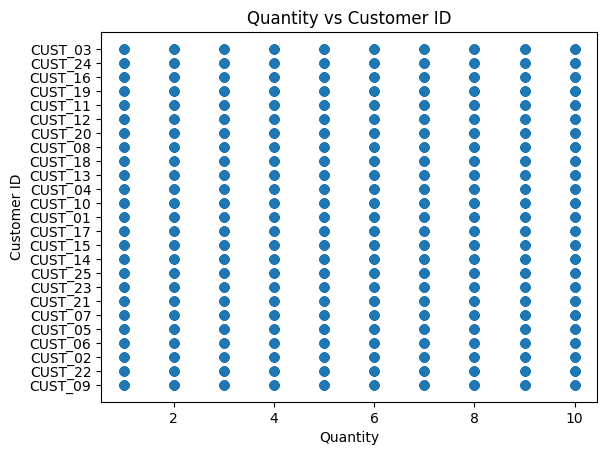

In [97]:
import matplotlib.pyplot as plt

plt.scatter(df["Quantity"], df["Customer ID"])
plt.xlabel("Quantity")
plt.ylabel("Customer ID")
plt.title("Quantity vs Customer ID")
plt.show()

# Convert date column to datetime


In [98]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# 1. SALES PERFORMANCE

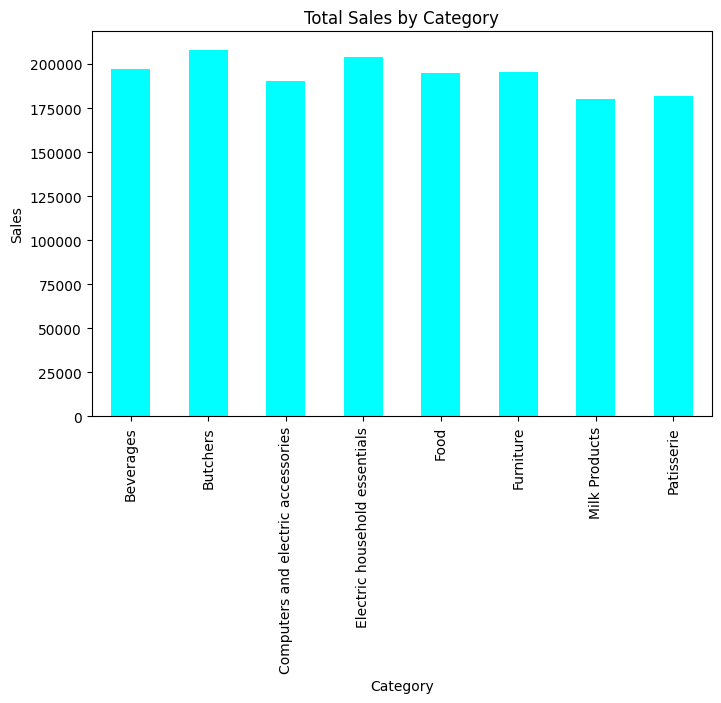

In [99]:

# Total sales by category
category_sales = df.groupby('Category')['Total Spent'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar',color='cyan')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Most sold items


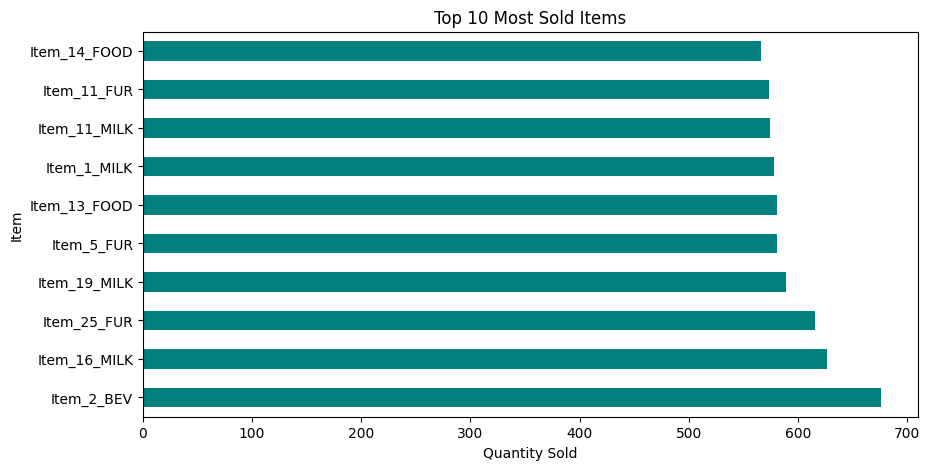

In [100]:
item_quantity = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
item_quantity.plot(kind='barh', color='teal')
plt.title("Top 10 Most Sold Items")
plt.xlabel("Quantity Sold")
plt.show()

# Online vs In-store sales


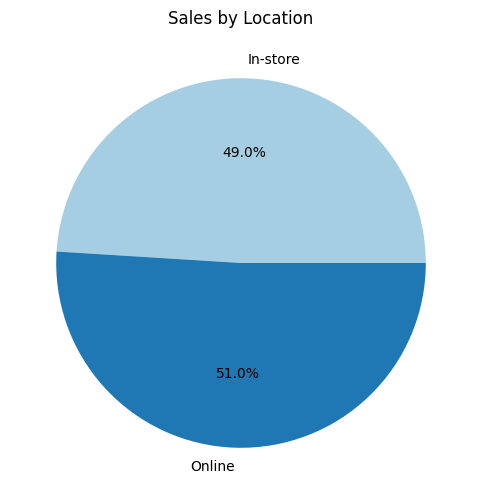

In [101]:
location_sales = df.groupby('Location')['Total Spent'].sum()

plt.figure(figsize=(6,6))
location_sales.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors)
plt.title("Sales by Location")
plt.show()

# 2. CUSTOMER BUYING BEHAVIOR

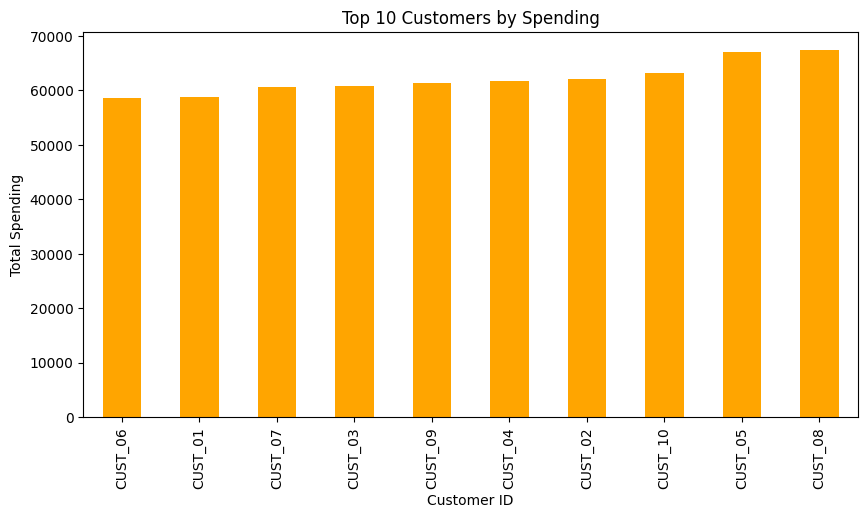

In [102]:


# Top customers
top_customers = df.groupby('Customer ID')['Total Spent'].sum().head(10).sort_values(ascending=True)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar', color='orange')
plt.title("Top 10 Customers by Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.show()

In [103]:
# Average quantity purchased
avg_quantity = df['Quantity'].mean()
print("Average Quantity Purchased:", avg_quantity)

Average Quantity Purchased: 5.536379583994654


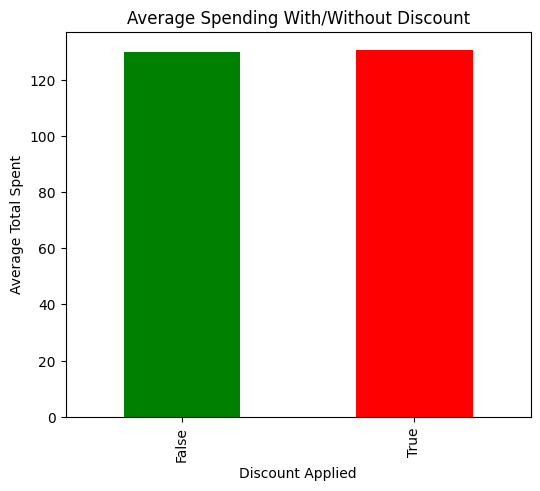

In [104]:
# Discount impact
discount_sales = df.groupby('Discount Applied')['Total Spent'].mean()

plt.figure(figsize=(6,5))
discount_sales.plot(kind='bar',color=['green','red'])
plt.title("Average Spending With/Without Discount")
plt.ylabel("Average Total Spent")
plt.show()

# 3. PAYMENT METHOD ANALYSIS

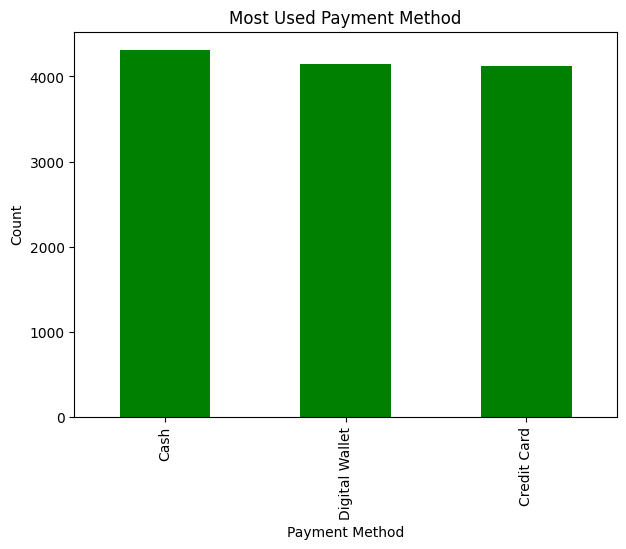

In [105]:
# Most used payment method
payment_count = df['Payment Method'].value_counts()

plt.figure(figsize=(7,5))
payment_count.plot(kind='bar',color='g')
plt.title("Most Used Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

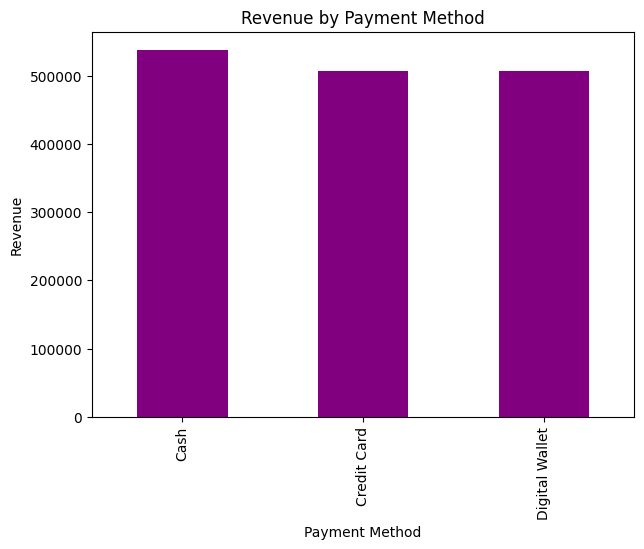

In [106]:
# Highest revenue payment method
payment_revenue = df.groupby('Payment Method')['Total Spent'].sum()

plt.figure(figsize=(7,5))
payment_revenue.plot(kind='bar',color='purple')
plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")
plt.show()

# 4. DISCOUNT ANALYSIS

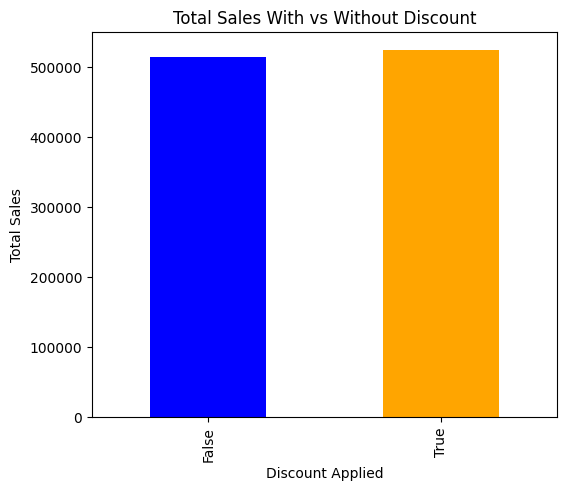

In [107]:


# Compare spending with/without discount
discount_compare = df.groupby('Discount Applied')['Total Spent'].sum()

plt.figure(figsize=(6,5))
discount_compare.plot(kind='bar', color=['blue','orange'])
plt.title("Total Sales With vs Without Discount")
plt.ylabel("Total Sales")
plt.show()

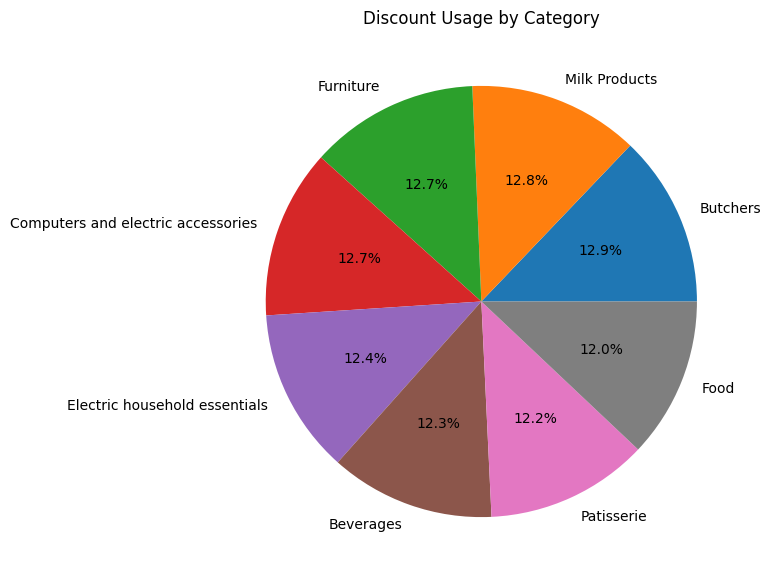

In [108]:
# Categories using discounts most
discount_category = df[df['Discount Applied'] == True]['Category'].value_counts()

plt.figure(figsize=(7,7))
discount_category.plot(kind='pie', autopct='%1.1f%%')
plt.title("Discount Usage by Category")
plt.ylabel("")
plt.show()

<Figure size 700x500 with 0 Axes>

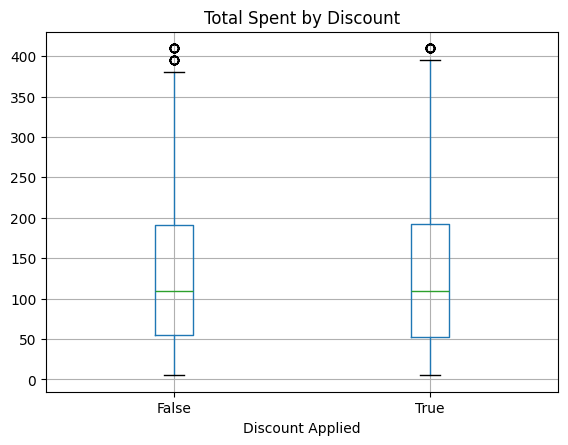

In [109]:
# Boxplot
plt.figure(figsize=(7,5))
df.boxplot(column='Total Spent', by='Discount Applied')
plt.title("Total Spent by Discount")
plt.suptitle("")
plt.show()

# 5. TIME-BASED ANALYSIS

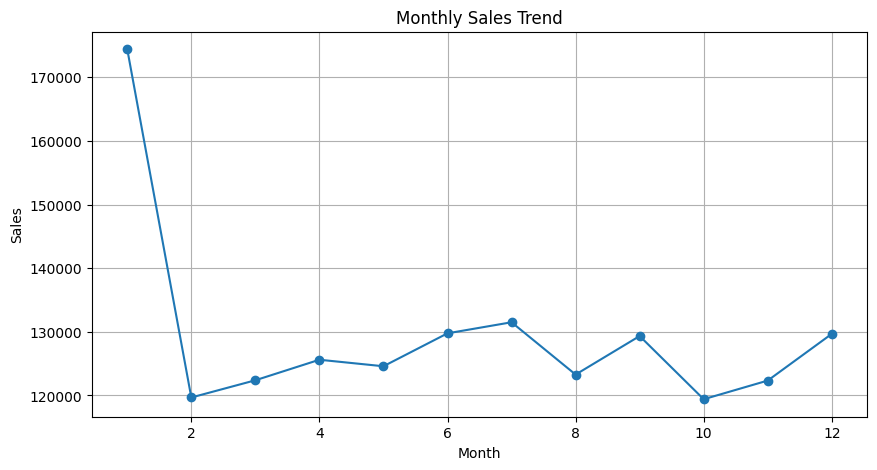

In [110]:
# Sales by month
df['Month'] = df['Transaction Date'].dt.month

monthly_sales = df.groupby('Month')['Total Spent'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

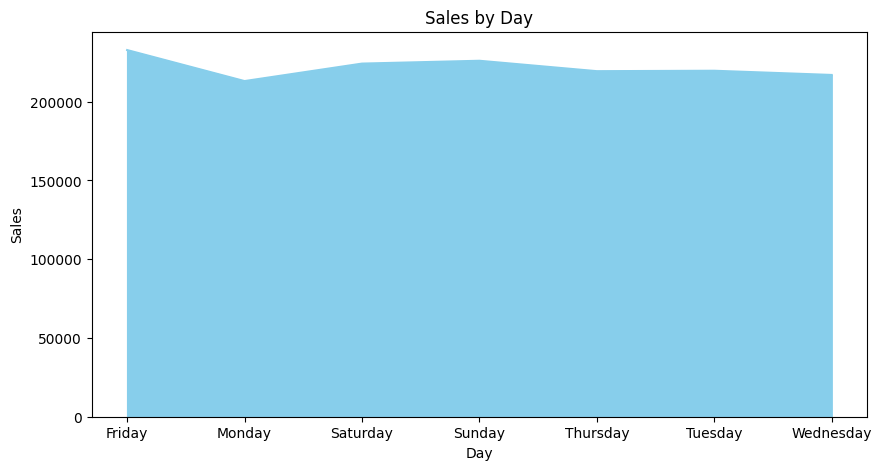

In [111]:
# Sales by day
df['Day'] = df['Transaction Date'].dt.day_name()

daily_sales = df.groupby('Day')['Total Spent'].sum()

plt.figure(figsize=(10,5))
daily_sales.plot(kind='area',color='skyblue')
plt.title("Sales by Day")
plt.ylabel("Sales")
plt.show()